## 1) Imports and Global Setup

In [1]:
import math
import os
import json
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from IPython.display import clear_output, display

# Reproducibility
torch.set_default_dtype(torch.float32)
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2) Environment Dynamics and Sampling

In [2]:
# State box
min_position, max_position = -0.99, 0.99
max_speed = 0.07
state_low = torch.tensor([min_position, -max_speed], device=device)
state_high = torch.tensor([max_position, max_speed], device=device)


def tg_alpha(x: torch.Tensor) -> torch.Tensor:
    return 0.1 * (
        2 * x / (1 - x ** 2)
        - 2 * math.pi * torch.sin(2 * math.pi * x)
        - 8 * math.pi * torch.sin(4 * math.pi * x)
    )


def next_state(s: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
    dt = 0.1
    force_mag = 0.001
    gravity = 0.0025
    x, v = s[:, 0], s[:, 1]
    f = (a.float() * 2 - 1) * force_mag + tg_alpha(x) * (-gravity)
    v = torch.clamp(v + f * dt, -max_speed, max_speed)
    x = torch.clamp(x + v * dt, min_position, max_position)
    return torch.stack([x, v], dim=1)


def sample_proposal(n: int) -> torch.Tensor:
    # Uniform over state box (this is the only training proposal used here)
    return state_low + torch.rand(n, 2, device=device) * (state_high - state_low)


def sample_start(n: int) -> torch.Tensor:
    # Initial-state distribution for discounted objective anchor term
    sign = torch.where(torch.rand(n, device=device) < 0.5, -1.0, 1.0)
    pos = sign * (torch.rand(n, device=device) * 0.1 + 0.67)
    vel = (torch.rand(n, device=device) * 2 - 1) * 0.01
    return torch.stack([pos, vel], dim=1)

## 3) Policy Network Loading (`mvmc.pth`)

In [3]:
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self._fc_policy = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 2)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self._fc_policy(x)


policy_net = PolicyNetwork().to(device)


def load_policy_from_triple_net_ckpt(policy_net: PolicyNetwork, ckpt_path: str):
    if not os.path.exists(ckpt_path):
        print(f"WARNING: '{ckpt_path}' not found. Using random policy.")
        return False

    try:
        sd = torch.load(ckpt_path, map_location=device)
        if not isinstance(sd, dict):
            raise ValueError('Checkpoint is not a state_dict-like dict.')

        new_sd = OrderedDict()
        for k, v in sd.items():
            k2 = k.replace('module.', '')
            if k2.startswith('_fc_policy.'):
                k3 = k2.replace('_fc_policy.', '')
                new_sd[k3] = v

        if len(new_sd) == 0:
            raise KeyError('No _fc_policy.* keys found in checkpoint.')

        policy_net._fc_policy.load_state_dict(new_sd, strict=True)
        policy_net.eval()
        print(f'SUCCESS: Loaded policy from {ckpt_path}')
        return True
    except Exception as e:
        print(f"ERROR loading policy from '{ckpt_path}': {e}")
        return False


_ = load_policy_from_triple_net_ckpt(policy_net, 'mvmc.pth')


@torch.no_grad()
def policy_probs(s: torch.Tensor) -> torch.Tensor:
    return torch.softmax(policy_net(s), dim=-1)


@torch.no_grad()
def sample_actions(s: torch.Tensor) -> torch.Tensor:
    return Categorical(logits=policy_net(s)).sample()

SUCCESS: Loaded policy from mvmc.pth


## 4) Ground Truth (for Evaluation Only)

This estimates discounted occupancy by Monte Carlo rollouts and is used only to evaluate learned density.


In [4]:
@torch.no_grad()
def estimate_state_histogram_discounted(gamma=0.99, n=120_000, t=800, x_bins=200, v_bins=200):
    x_edges = torch.linspace(state_low[0], state_high[0], x_bins + 1, device=device)
    v_edges = torch.linspace(state_low[1], state_high[1], v_bins + 1, device=device)
    h = torch.zeros((x_bins, v_bins), device=device, dtype=torch.float64)

    s = sample_start(n)
    w = 1.0 - gamma
    eps = 1e-12

    for _ in range(t):
        xv = torch.clamp(s[:, 0], x_edges[0], x_edges[-1] - eps)
        vv = torch.clamp(s[:, 1], v_edges[0], v_edges[-1] - eps)
        ix = torch.bucketize(xv, x_edges) - 1
        iv = torch.bucketize(vv, v_edges) - 1
        mask = (ix >= 0) & (ix < x_bins) & (iv >= 0) & (iv < v_bins)
        if mask.any():
            h.index_put_(
                (ix[mask], iv[mask]),
                torch.full((int(mask.sum().item()),), w, device=device, dtype=h.dtype),
                accumulate=True,
            )

        s = next_state(s, sample_actions(s))
        w *= gamma
        if w < 1e-12:
            break

    h = h / (h.sum() + 1e-12)
    return h, x_edges, v_edges


gamma = 0.99
x_bins, v_bins = 200, 200
gt_h_xv, x_edges, v_edges = estimate_state_histogram_discounted(
    gamma=gamma, n=120_000, t=800, x_bins=x_bins, v_bins=v_bins
)
gt_vx = gt_h_xv.T.contiguous()
print('GT mass:', float(gt_vx.sum().item()))

GT mass: 0.9999999999999999


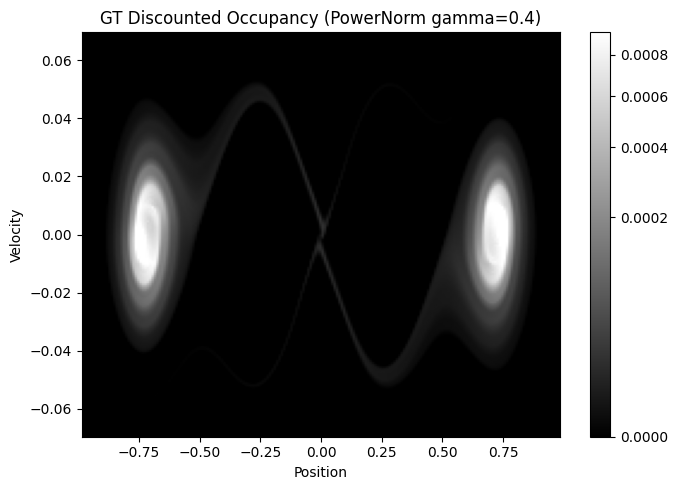

In [5]:
# Quick GT visualization (PowerNorm gamma=0.4)
xc = 0.5 * (x_edges[:-1] + x_edges[1:])
vc = 0.5 * (v_edges[:-1] + v_edges[1:])
extent = [float(xc[0]), float(xc[-1]), float(vc[0]), float(vc[-1])]

gt_np = gt_vx.detach().cpu().numpy()
vmax = max(float(np.quantile(gt_np, 0.995)), 1e-8)

plt.figure(figsize=(7, 5))
plt.imshow(
    gt_np,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap='gray',
    norm=PowerNorm(gamma=0.4, vmin=0.0, vmax=vmax),
)
plt.title('GT Discounted Occupancy (PowerNorm gamma=0.4)')
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.colorbar()
plt.tight_layout()
plt.show()

## 5) State-Only Networks (`nu(s)`, `zeta(s)`)


## SIREN (Sinusoidal Representation Network) Architecture

### Architecture Diagram

```text
           Input Tensor `s` 
             Shape: [N, 2]
                   │
                   ▼
  ┌─────────────────────────────────┐
  │ 1. InputScale                   │
  │    Multiplies dimension 0 by 1.0│
  │    Multiplies dimension 1 by    │
  │    ~14.28 (which is 1/0.07)     │
  └─────────────────────────────────┘
                   │ Shape: [N, 2]
                   ▼
  ┌─────────────────────────────────┐
  │ 2. SineLayer (is_first=True)    │
  │    Linear(in=2, out=256)        │
  │    Weights initialized specially│
  │    Act: sin(30.0 * x)           │
  └─────────────────────────────────┘
                   │ Shape: [N, 256]
                   ▼
  ┌─────────────────────────────────┐
  │ 3. SineLayer (Hidden 1)         │
  │    Linear(in=256, out=256)      │
  │    Act: sin(4.0 * x)            │
  └─────────────────────────────────┘
                   │ Shape: [N, 256]
                   ▼
                   ...
         (Repeats 3 more times 
          for a total of 4 hidden)
                   ...
                   │ Shape: [N, 256]
                   ▼
  ┌─────────────────────────────────┐
  │ 4. SineLayer (Hidden 4)         │
  │    Linear(in=256, out=256)      │
  │    Act: sin(4.0 * x)            │
  └─────────────────────────────────┘
                   │ Shape: [N, 256]
                   ▼
  ┌─────────────────────────────────┐
  │ 5. Head                         │
  │    Linear(in=256, out=1)        │
  │    No activation applied here   │
  └─────────────────────────────────┘
                   │ Shape: [N, 1]
                   ▼
  ┌─────────────────────────────────┐
  │ 6. Output Processing            │
  │    If `out_positive` == True:   │
  │        Apply Softplus()         │
  │    Else:                        │
  │        Do nothing (Identity)    │
  └─────────────────────────────────┘
                   │
                   ▼
            Final Output 
             Shape: [N, 1]

```

---

### Layer-by-Layer Mathematical Breakdown

**1. Input Scaling**
The raw 2D input coordinates are scaled anisotropically. This is usually done to normalize coordinates to a specific domain range.


$$x_{scaled} = s \odot [1.0, \frac{1}{0.07}]$$

**2. First Sine Layer**
SIRENs require a special initialization scheme and a high frequency multiplier for the very first layer so that the network spans multiple periods over the input domain.

* **Formula:** 
$$x_1 = \sin(\omega_{first} \cdot (W_0 x_{scaled} + b_0))$$


* **Parameters:** $\omega_{first} = 30.0$, and $W_0 \sim U(-\frac{1}{2}, \frac{1}{2})$

**3. Hidden Layers (Depth - 1 times)**
The subsequent layers maintain the hidden dimension size and use a lower frequency multiplier to preserve the features.

* **Formula:** 
$$x_i = \sin(\omega_{hidden} \cdot (W_{i-1} x_{i-1} + b_{i-1}))$$


* **Parameters:** $\omega_{hidden} = 4.0$, and $W_{i-1} \sim U(-\frac{\sqrt{6/d_{in}}}{\omega_{hidden}}, \frac{\sqrt{6/d_{in}}}{\omega_{hidden}})$

**4. Linear Head**
The final hidden representation is compressed down to a single scalar value.

* **Formula:** 
$$y_{logits} = W_{head} x_N + b_{head}$$



**5. Final Activation**
Depending on what you are modeling, the output might need to be strictly positive (e.g., density or unsigned distance).

* **Formula:** 
$$y = \ln(1 + e^{y_{logits}})$$


 (if `out_positive` is true), otherwise $y = y_{logits}$



In [6]:
class InputScale(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('scale', torch.tensor([1.0, 1.0 / 0.07], device=device))

    def forward(self, s: torch.Tensor) -> torch.Tensor:
        return s * self.scale


class SineLayer(nn.Module):
    def __init__(self, in_dim, out_dim, omega_0=30.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.omega_0 = omega_0
        self.is_first = is_first
        self.reset_parameters()

    def reset_parameters(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1.0 / self.linear.in_features
            else:
                bound = np.sqrt(6.0 / self.linear.in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class SirenMLP(nn.Module):
    def __init__(self, out_positive=False, hidden_dim=256, depth=5, omega_first=30.0, omega_hidden=4.0):
        super().__init__()
        self.scaler = InputScale()
        layers = [SineLayer(2, hidden_dim, omega_0=omega_first, is_first=True)]
        for _ in range(depth - 1):
            layers.append(SineLayer(hidden_dim, hidden_dim, omega_0=omega_hidden, is_first=False))
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(hidden_dim, 1)
        with torch.no_grad():
            b = np.sqrt(6.0 / hidden_dim) / omega_hidden
            self.head.weight.uniform_(-b, b)
            if out_positive:
                self.head.bias.fill_(-5.0)
            else:
                self.head.bias.zero_()
            self.out_positive = out_positive
            self.softplus = nn.Softplus()

    def forward(self, s: torch.Tensor):
        x = self.scaler(s)
        x = self.body(x)
        x = self.head(x)
        return self.softplus(x) if self.out_positive else x

## 6) One-Step Uniform Batch Sampler and DualDICE Losses

$$
\begin{aligned}
&\min_{\nu: \mathcal{S} \times \mathcal{A} \to \mathbb{R}} \max_{\zeta: \mathcal{S} \times \mathcal{A} \to \mathbb{R}} J(\nu, \zeta) := \\
&\mathbb{E}_{(s,a,s') \sim d^D,\, a' \sim \pi(s')}\left[(\nu(s,a) - \gamma \nu(s',a'))\zeta(s,a) - \frac{\zeta(s,a)^2}{2}\right] \\
&\quad - (1 - \gamma)\, \mathbb{E}_{s_0 \sim \beta,\, a_0 \sim \pi(s_0)}\left[\nu(s_0, a_0)\right].
\end{aligned}
$$


Instead of using state action I am using state only

In [7]:
@torch.no_grad()
def sample_dual_dice_batch(batch_size=10_000):
    s = sample_proposal(batch_size) 
    a = sample_actions(s)
    sp = next_state(s, a)
    s0 = sample_start(batch_size)
    return {'s': s, 'a': a, 'sp': sp, 's0': s0}


def dual_dice_losses(
    nu_net,
    zeta_net,
    batch,
    gamma,
):
    s = batch['s']
    s0 = batch['s0']

    nu_s = nu_net(s).squeeze(-1)
    nu_s0 = nu_net(s0).squeeze(-1)

    with torch.no_grad():
        pi = policy_probs(s)
    a0 = torch.zeros(s.shape[0], device=s.device, dtype=torch.long)
    a1 = torch.ones(s.shape[0], device=s.device, dtype=torch.long)
    sp0 = next_state(s, a0)
    sp1 = next_state(s, a1)
    nu_next = pi[:, 0] * nu_net(sp0).squeeze(-1) + pi[:, 1] * nu_net(sp1).squeeze(-1)

    delta = nu_s - gamma * nu_next
    zeta = zeta_net(s).squeeze(-1)

    zeta_loss = (0.5 * zeta.pow(2) - delta.detach() * zeta).mean()

    nu_loss = (delta * zeta.detach()).mean() - (1.0 - gamma) * nu_s0.mean()

    stats = {
        'nu_loss': float(nu_loss.detach().item()),
        'zeta_loss': float(zeta_loss.detach().item()),
        'delta_abs_mean': float(delta.detach().abs().mean().item()),
        'zeta_mean': float(zeta.detach().mean().item()),
        'zeta_min': float(zeta.detach().min().item()),
    }
    return {'nu_loss': nu_loss, 'zeta_loss': zeta_loss, 'stats': stats}

## 7) Prediction Grid, Metrics, and Plotting

In [8]:
@torch.no_grad()
def predict_density_grid(zeta_net: nn.Module, x_bins: int, v_bins: int):
    x_edges = torch.linspace(state_low[0], state_high[0], x_bins + 1, device=device)
    v_edges = torch.linspace(state_low[1], state_high[1], v_bins + 1, device=device)
    xc = 0.5 * (x_edges[:-1] + x_edges[1:])
    vc = 0.5 * (v_edges[:-1] + v_edges[1:])

    vg, xg = torch.meshgrid(vc, xc, indexing='ij')
    s = torch.stack([xg.flatten(), vg.flatten()], dim=1)
    z = torch.clamp(zeta_net(s).squeeze(-1), min=0.0)

    h = z.reshape(v_bins, x_bins)
    h = h / (h.sum() + 1e-12)
    return h, xc, vc


def plot_pair(gt_vx, pred_vx, xc, vc, title='', out_path=None):
    extent = [float(xc[0]), float(xc[-1]), float(vc[0]), float(vc[-1])]
    gt_np = gt_vx.detach().cpu().numpy()
    pred_np = pred_vx.detach().cpu().numpy()
    vmax_main = float(max(np.quantile(np.maximum(gt_np, pred_np), 0.995), 1e-8))
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    # Subplot 1: Ground Truth
    im0 = ax[0].imshow(gt_np, origin='lower', extent=extent, aspect='auto', cmap='gray',
                       norm=PowerNorm(gamma=0.4, vmin=0.0, vmax=vmax_main))
    ax[0].set_title('GT (PowerNorm gamma=0.4)')
    ax[0].set_xlabel('Position')
    ax[0].set_ylabel('Velocity')
    fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    # Subplot 2: Predicted Distribution
    im1 = ax[1].imshow(pred_np, origin='lower', extent=extent, aspect='auto', cmap='gray',
                       norm=PowerNorm(gamma=0.4, vmin=0.0, vmax=vmax_main))
    ax[1].set_title('DualDICE Pred (PowerNorm gamma=0.4)')
    ax[1].set_xlabel('Position')
    # No need to set y-label here since sharey=True handles it visually
    fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

    fig.suptitle(title, y=1.02)
    fig.tight_layout()

    # Save to disk if requested
    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        
    plt.show()

## 8) Training Configuration 


if nu_loss start increasing reduce learning rates

if zeta predicting exactly zero increase zeta updates

In [ ]:
cfg = {
    'gamma': 0.99,
    'steps': 100_000,
    'batch_size': 10000,
    'lr_nu': 1e-5,
    'lr_zeta': 1e-5,
    'grad_clip': 1,
    'zeta_updates': 5,
    'nu_updates': 1,
    'hidden_dim': 512,
    'depth': 5,
    'omega_first': 30.0,
    'omega_hidden': 4.0,
    'viz_every': 2000,
    'log_every': 1000,
    'weight_decay_nu': 1e-5,
    'weight_decay_z': 1e-5,
}

## 9) Train (Live Visualization Every `viz_every` Steps)

Step 16000 | Nu Loss: -4.4591 | Zeta Loss: -1.1442


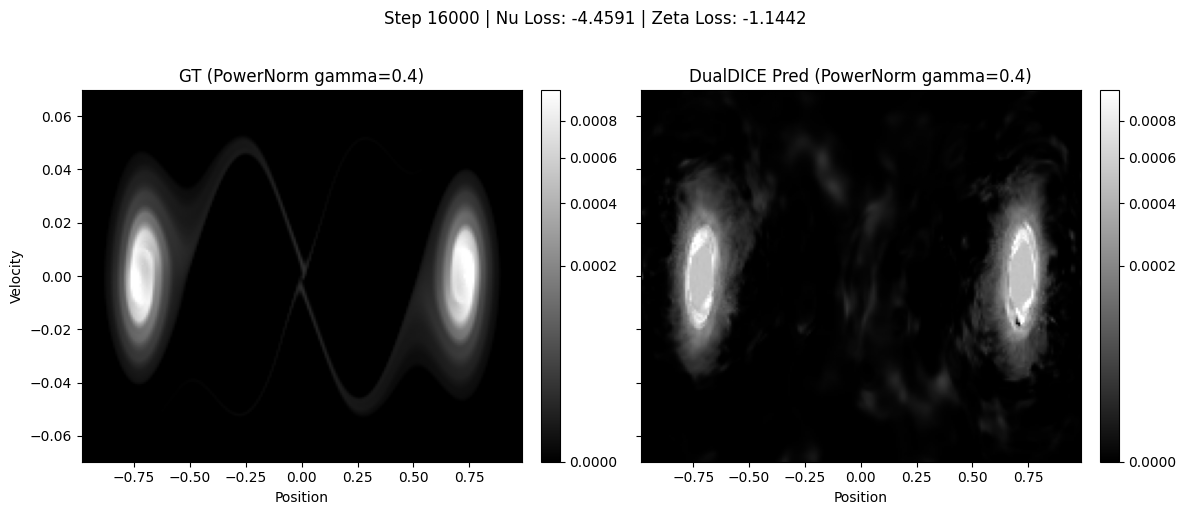

KeyboardInterrupt: 

In [10]:
run_dir = Path('notebook_state_only_final') / f"seed_{seed}"
snap_dir = run_dir / 'snapshots'
snap_dir.mkdir(parents=True, exist_ok=True)

import torch.nn.functional as F # Ensure this is imported if you calculate losses later

nu_net = SirenMLP(
    out_positive=False,
    hidden_dim=cfg['hidden_dim'],
    depth=cfg['depth'],
    omega_first=cfg['omega_first'],
    omega_hidden=cfg['omega_hidden'],
).to(device)

zeta_net = SirenMLP(
    out_positive=True,
    hidden_dim=cfg['hidden_dim'],
    depth=cfg['depth'],
    omega_first=cfg['omega_first'],
    omega_hidden=cfg['omega_hidden'],
).to(device)

opt_nu = optim.Adam(nu_net.parameters(), lr=cfg['lr_nu'], weight_decay=cfg['weight_decay_nu'])
opt_z = optim.Adam(zeta_net.parameters(), lr=cfg['lr_zeta'], weight_decay=cfg['weight_decay_z'])

logs = []

for step in range(1, cfg['steps'] + 1):
    # zeta ascent/descent step(s)
    for _ in range(cfg['zeta_updates']):
        b = sample_dual_dice_batch(cfg['batch_size'])
        opt_z.zero_grad(set_to_none=True)
        out = dual_dice_losses(nu_net, zeta_net, b, gamma=cfg['gamma'])
        out['zeta_loss'].backward()
        torch.nn.utils.clip_grad_norm_(zeta_net.parameters(), cfg['grad_clip'])
        opt_z.step()

    # nu step(s)
    for _ in range(cfg['nu_updates']):
        b = sample_dual_dice_batch(cfg['batch_size'])
        opt_nu.zero_grad(set_to_none=True)
        out = dual_dice_losses(nu_net, zeta_net, b, gamma=cfg['gamma'])
        out['nu_loss'].backward()
        torch.nn.utils.clip_grad_norm_(nu_net.parameters(), cfg['grad_clip'])
        opt_nu.step()

    # Logging
    if step == 1 or step % cfg['log_every'] == 0:
        b = sample_dual_dice_batch(cfg['batch_size'])
        with torch.no_grad():
            stats = dual_dice_losses(nu_net, zeta_net, b, gamma=cfg['gamma'])['stats']
        stats['step'] = step
        logs.append(stats)
        print(f"[step {step:5d}] nu={stats['nu_loss']:.4e} zeta={stats['zeta_loss']:.4e} "
              f"delta={stats['delta_abs_mean']:.4e} zmean={stats['zeta_mean']:.4f}")

    # Visualization
    if step % cfg['viz_every'] == 0 or step == cfg['steps']:
        with torch.no_grad():
            pred_vx, xc, vc = predict_density_grid(zeta_net, x_bins, v_bins)
        out_path = snap_dir / f"step_{step:07d}.png"
        current_title = f"Step {step} | Nu Loss: {stats['nu_loss']:.4f} | Zeta Loss: {stats['zeta_loss']:.4f}"
        clear_output(wait=True)
        print(current_title) 
        plot_pair(gt_vx, pred_vx, xc, vc, title=current_title, out_path=out_path)

pred_vx, xc, vc = predict_density_grid(zeta_net, x_bins, v_bins)
plot_pair(
    gt_vx, pred_vx, xc, vc,
    title=f"FINAL DISTRIBUTION | Step {cfg['steps']}",
    out_path=run_dir / 'final_pair.png',
)

Nu loss is more negative then zeta loss like [step 39000] nu=-4.8846e+00 zeta=-2.0490e+00 delta=7.3722e-01 zmean=0.4426 and overall my zmean is increased.